In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import NMF

import matplotlib.pyplot as plt

In [5]:
import os

path = os.path.join(os.getcwd(), "outputs", "communication_matrix.csv")
print(path)
print(os.path.exists(path))

C:\BRCA\BRCA Project\outputs\communication_matrix.csv
False


Current working directory:
C:\BRCA\BRCA Project

Files here:
.ipynb_checkpoints
01_atlas_exploration.ipynb
02_metadata_integration.ipynb
03_single_patient_exploration.ipynb
04_cell_cell_communication_FIXED.ipynb
05_patient_communication_matrix.ipynb
06_communication_program_discovery.ipynb
data
figures
FirstStepConda.txt
logs
manuscripts
models
Notebook6.txt
NotebookPipeline.txt
notebooks
notebooktextfiles
papers
Project Notes.docx
results
Running file.txt
scripts


In [8]:
from pathlib import Path

path = Path("data/outputs/communication_matrix.csv")

print(path)
print(path.exists())

data\outputs\communication_matrix.csv
True


In [9]:
import pandas as pd

communication_matrix = pd.read_csv(
    "data/outputs/communication_matrix.csv",
    index_col=0
)

communication_matrix.shape

(138, 3489)

In [10]:
communication_matrix = pd.read_csv(
    "data/outputs/communication_matrix.csv",
    index_col=0
)

print(communication_matrix.shape)

communication_matrix.head()

(138, 3489)


,LGALS9→PTPRC,LGALS9→MET,LGALS9→CD44,LGALS9→LRP1,LGALS9→CD47,LGALS9→PTPRK,LGALS9→COLEC12,LGALS9→HAVCR2,LGALS9→MRC2,DLL1→NOTCH1,...,BMP6→AMHR2,GDF11→ACTR2,GDF1→ACTR2,INHBA→ACTR2,BMP7→ACTR2,BMP2→ACTR2,BMP15→ACTR2,CSF1→CSF3R,IL36G→IFNAR1,IL36G→IFNAR2
wu_natgen_CID3586,8.633867,1.044805,8.393451,0.776248,3.758318,1.168318,0.296762,3.943516,0.637201,0.292995,...,0.000000e+00,0.546232,0.0,1.127656,0.008232,0.995683,0.0,0.114970,0.000000,0.000000
wu_natgen_CID3921,7.129786,0.670546,9.661072,2.296553,5.089897,1.524040,0.145497,2.765677,0.596229,0.356648,...,0.000000e+00,0.241065,0.0,2.798962,0.346355,0.568526,0.0,0.149420,0.000000,0.000000
wu_natgen_CID45171,8.077541,0.145614,7.158105,0.689071,4.376402,1.669631,0.300532,0.799553,0.391112,0.017953,...,0.000000e+00,2.182149,0.0,0.993794,0.057089,0.080615,0.0,0.032563,0.000000,0.000000
wu_natgen_CID3838,16.582199,2.095036,17.671549,3.576852,10.819265,2.728356,1.450304,5.477222,2.551522,2.010751,...,5.337549e-06,7.685503,0.0,7.648826,0.520871,3.494657,0.0,0.315217,0.003883,0.003169
wu_natgen_CID4066,6.538203,0.480212,4.661026,1.018777,4.621882,1.056085,0.198088,1.693815,0.611983,0.456659,...,6.623769e-07,0.439607,0.0,1.183399,0.088907,0.741925,0.0,0.104455,0.000000,0.000000


In [11]:
print("Patients:", communication_matrix.shape[0])
print("Features:", communication_matrix.shape[1])

print("\nMissing values:")
print(communication_matrix.isna().sum().sum())

zero_fraction = (communication_matrix == 0).mean().mean()

print("\nFraction of zeros:")
print(round(zero_fraction,3))

Patients: 138
Features: 3489

Missing values:
0

Fraction of zeros:
0.377


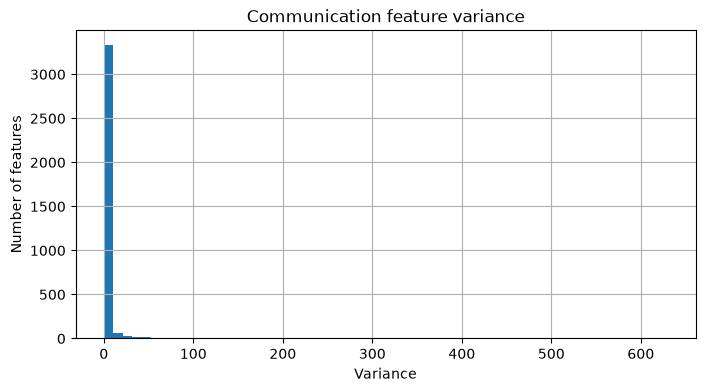

count    3489.000000
mean        2.744499
std        20.378662
min         0.000000
25%         0.000048
50%         0.007165
75%         0.323429
max       629.703092
dtype: float64

In [12]:
feature_variance = communication_matrix.var(axis=0)

plt.figure(figsize=(8,4))
feature_variance.hist(bins=60)

plt.xlabel("Variance")
plt.ylabel("Number of features")
plt.title("Communication feature variance")

plt.show()

feature_variance.describe()

In [13]:
filtered_matrix = communication_matrix.loc[
    :,
    feature_variance > 0
]

print(filtered_matrix.shape)

(138, 3465)


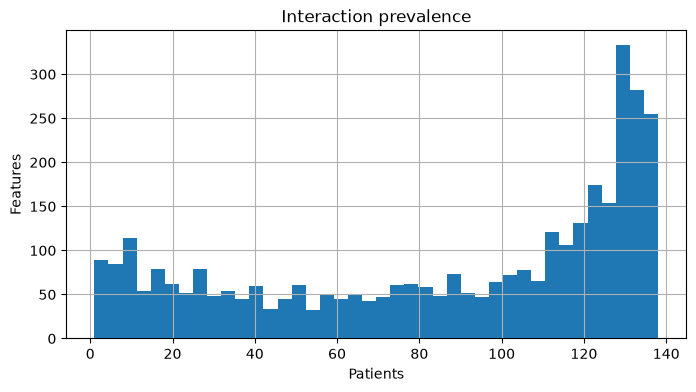

count    3465.000000
mean       86.501010
std        44.862383
min         1.000000
25%        46.000000
50%       102.000000
75%       128.000000
max       138.000000
dtype: float64

In [14]:
presence = (filtered_matrix > 0).sum(axis=0)

plt.figure(figsize=(8,4))

presence.hist(bins=40)

plt.xlabel("Patients")
plt.ylabel("Features")
plt.title("Interaction prevalence")

plt.show()

presence.describe()

In [15]:
corr = communication_matrix.corr(method="spearman")

print(corr.shape)

(3489, 3489)


In [16]:
import numpy as np

corr = corr.fillna(0)

np.fill_diagonal(corr.values, 1)

print(corr.min().min(), corr.max().max())

-0.6926811001452138 1.0


In [17]:
distance = 1 - np.abs(corr)

distance = distance.clip(lower=0, upper=1)

np.fill_diagonal(distance.values, 0)

print(distance.min().min(), distance.max().max())

0.0 1.0


In [18]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage

condensed = squareform(distance.values)

Z = linkage(condensed, method="average")

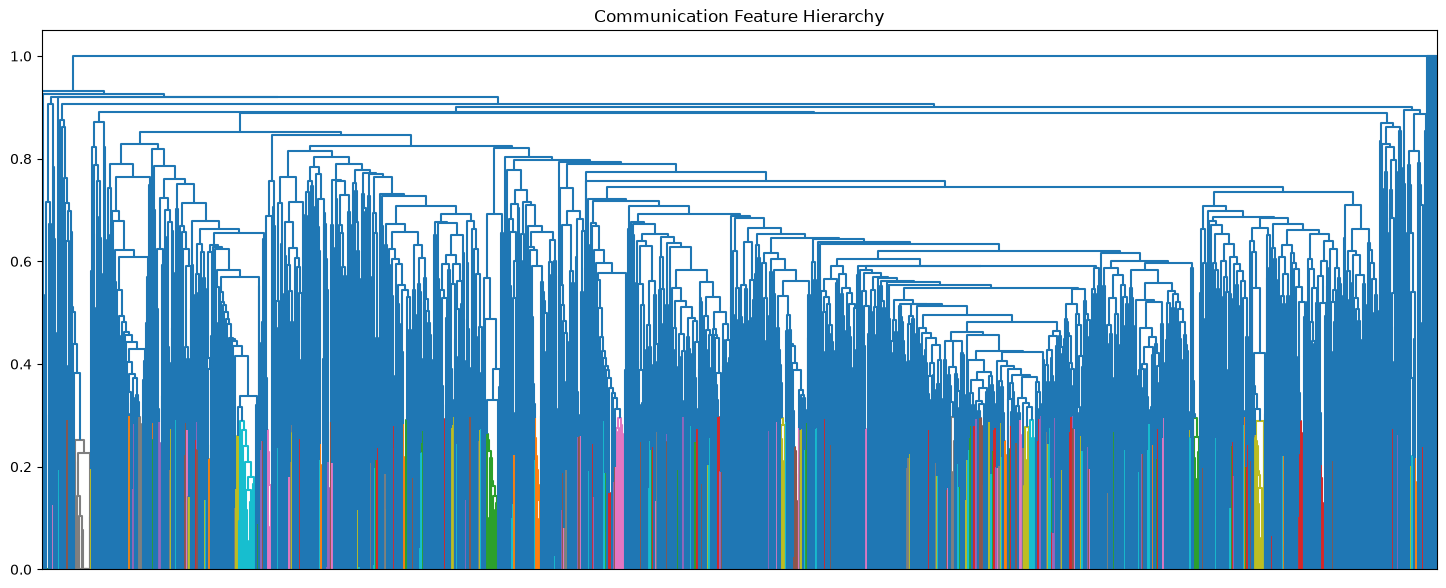

In [22]:
plt.figure(figsize=(18,7))

dendrogram(
    Z,
    no_labels=True,
    color_threshold=0.3
)

plt.title("Communication Feature Hierarchy")
plt.show()

In [20]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(
    Z,
    t=0.7,
    criterion="distance"
)

program_df = pd.DataFrame({
    "feature": communication_matrix.columns,
    "program": clusters
})

print(program_df["program"].value_counts().head(15))

program
87    1424
89     341
37     185
71     125
70     122
24      94
85      93
91      83
79      78
13      65
81      63
72      55
43      45
36      32
56      26
Name: count, dtype: int64


In [21]:
for p in program_df["program"].value_counts().index[:10]:
    print(f"\nProgram {p}")
    display(program_df[program_df.program == p].head(20))


Program 87


,feature,program
0,LGALS9→PTPRC,87
1,LGALS9→MET,87
2,LGALS9→CD44,87
3,LGALS9→LRP1,87
4,LGALS9→CD47,87
5,LGALS9→PTPRK,87
6,LGALS9→COLEC12,87
7,LGALS9→HAVCR2,87
8,LGALS9→MRC2,87
9,DLL1→NOTCH1,87



Program 89


,feature,program
44,ADAM11→ITGA4,89
100,ANXA1→GRM7,89
139,FCER2→CR2,89
182,TGFB3→ITGB6,89
197,NCAM1→FGFR1,89
201,NCAM1→ROBO3,89
202,NCAM1→ROBO1,89
248,EFNA1→EPHA5,89
251,EFNA1→EPHA7,89
306,TNFSF10→TNFRSF11B,89



Program 37


...

,feature,program
33,ADAM12→ITGA9,91
35,TNFSF12→CD163,91
104,HLA-A→ERBB2,91
143,THBS1→TNFRSF11B,91
151,THBS1→PTPRJ,91
204,CEACAM1→HAVCR2,91
212,SELL→MADCAM1,91
304,FLT3LG→FLT3,91
374,EFNB1→EPHB6,91
375,EFNB1→ERBB2,91



Program 79


,feature,program
31,EREG→ERBB3,79
61,TGFA→ERBB3,79
62,TGFA→ERBB4,79
189,CDH1→LRP5,79
191,CDH1→IGF1R,79
192,CDH1→PTPRF,79
200,NCAM1→GFRA1,79
252,EFNA1→EPHA10,79
283,BTC→ERBB3,79
316,EFNA4→EPHA10,79



Program 13


,feature,program
99,ANXA1→MTNR1A,13
126,APP→MTNR1A,13
767,CORT→MTNR1A,13
781,CCL21→MTNR1A,13
800,CXCL11→MTNR1A,13
817,CCL25→MTNR1A,13
824,CCL16→MTNR1A,13
858,CXCL13→MTNR1A,13
977,AGT→MTNR1A,13
1056,POMC→MTNR1A,13


In [23]:
from scipy.cluster.hierarchy import fcluster

for t in [0.2,0.3,0.4,0.5,0.6,0.7]:
    labels = fcluster(Z, t=t, criterion="distance")

    sizes = pd.Series(labels).value_counts()

    print(
        f"threshold={t}",
        "| clusters:", len(sizes),
        "| largest:", sizes.iloc[0],
        "| median:", sizes.median()
    )

threshold=0.2 | clusters: 2502 | largest: 34 | median: 1.0
threshold=0.3 | clusters: 1837 | largest: 42 | median: 1.0
threshold=0.4 | clusters: 1210 | largest: 110 | median: 2.0
threshold=0.5 | clusters: 702 | largest: 363 | median: 2.0
threshold=0.6 | clusters: 339 | largest: 608 | median: 3.0
threshold=0.7 | clusters: 144 | largest: 1424 | median: 4.0
